In [18]:
import pandas as pd
import numpy as np
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
import streamlit as st

warnings.filterwarnings('ignore')



In [19]:
#load data
df = pd.read_csv('new_york_real_estate_2026_final.csv')
print(f"Dataset Loaded: {df.shape[0]} rows and {df.shape[1]} columns")
df.head()

Dataset Loaded: 8273 rows and 11 columns


,type,sub_type,text,listPrice,sqft,stories,beds,baths,baths_full,baths_full_calc,garage
0,single_family,NaN,No description provided.,325000.0,1252.0,2.0,3.0,2.0,2.0,2.0,1.0
1,single_family,NaN,Shortsale.,308000.0,NaN,NaN,4.0,4.0,4.0,4.0,NaN
2,multi_family,NaN,Discover an exceptional investment opportunity...,799999.0,NaN,NaN,11.0,6.0,7.0,7.0,1.0
3,single_family,NaN,Classic Cape Cod with 4 bedrooms and 2 full ba...,189900.0,1400.0,3.0,4.0,2.0,2.0,2.0,2.0
4,single_family,NaN,"Spacious 4-bedroom, 2.5-bath two-story home of...",204900.0,2074.0,2.0,4.0,2.0,2.0,2.0,2.0


In [20]:
# إزالة الصفوف المكررة
initial_rows = len(df)
df.drop_duplicates(inplace=True)
print(f"Removed {initial_rows - len(df)} duplicate rows.")

# Missing Values
# تعبئة القيم المفقودة في المساحة بالوسيط (Median)
df['sqft'] = df['sqft'].fillna(df['sqft'].median())

# حذف الصفوف التي لا تحتوي على سعر (لأنها هدف التحليل الأساسي)
df.dropna(subset=['listPrice'], inplace=True)

#  إنشاء متغيرات جديدة (Feature Engineering)
# حساب سعر القدم المربع
df['price_per_sqft'] = df['listPrice'] / df['sqft']

print("Data Cleaning Completed.")

Removed 0 duplicate rows.
Data Cleaning Completed.


In [31]:
# الرسم الأول توزيع أسعار العقارات (Histogram)
fig1 = px.histogram(df, x="listPrice", title="Distribution of Property Prices", 
                   labels={'listPrice':'Price ($)'}, color_discrete_sequence=['#636EFA'])
fig1.show()

fig1.update_layout(xaxis_tickformat='$') # يضيف علامة الدولار

# الرسم الثاني أنواع العقارات (Pie Chart)
fig2 = px.pie(df, names='type', title="Property Types Distribution", hole=0.3, template="plotly_white")
fig2.show()

fig3 = px.scatter(df, x="sqft", y="listPrice", color="type",
                  title="Price vs. Square Footage",
                  hover_data=['beds', 'baths'],
                  template="plotly_white") # ضيف السطر ده
fig3.show()


In [29]:
# الرسم الثالث: العلاقة بين المساحة والسعر (Scatter Plot)
fig3 = px.scatter(df, x="sqft", y="listPrice", color="type", 
                 title="Price vs. Square Footage", hover_data=['beds', 'baths'],
                 template="plotly_white")
fig3.show()

# الرسم الرابع: متوسط الأسعار حسب عدد الغرف (Bar Chart)
avg_price_beds = df.groupby('beds')['listPrice'].mean().reset_index()
fig4 = px.bar(avg_price_beds, x='beds', y='listPrice', title="Average Price by Number of Bedrooms",
              template="plotly_white")
fig4.show()

# الرسم الخامس: تحليل القيم الشاذة للأسعار حسب النوع (Box Plot)
fig5 = px.box(df, x="type", y="listPrice", title="Price Range by Property Type", log_y=True,
              template="plotly_white")
fig5.show()

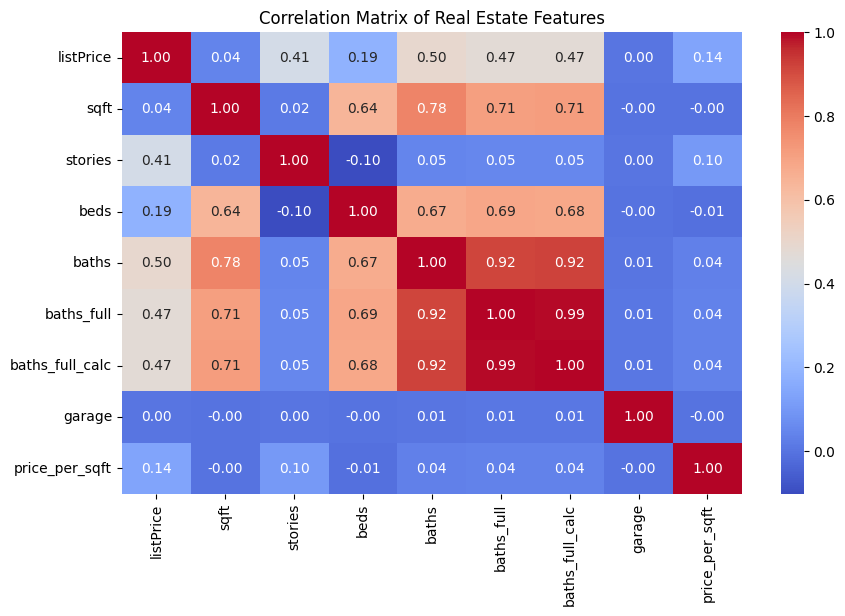

In [30]:
# الرسم السادس: مصفوفة الارتباط بين المتغيرات الرقمية
plt.figure(figsize=(10, 6))
correlation_matrix = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Real Estate Features")
plt.show()

In [24]:
# SIDEBAR
with st.sidebar:
    st.markdown("## 🏙️ NY Real Estate 2026")
    st.markdown("---")
    page = st.radio(
        "Navigate",
        [
            "🏠 Overview",
            "🔍 Data Quality",
            "🧹 Data Cleaning",
            "📊 Univariate Analysis",
            "🔗 Multivariate Analysis",
            "💡 Key Insights",
        ],
    )
    st.markdown("---")
    st.markdown("**Dataset:** New York Real Estate 2026")
    st.markdown("**Source:** Compiled real-estate listings")
    st.markdown("**Rows:** ~8,273 | **Cols:** 11")

2026-04-10 10:56:47.190 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-10 10:56:47.190 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-10 10:56:47.190 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-10 10:56:47.190 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-10 10:56:47.190 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-10 10:56:47.190 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-10 10:56:47.205 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-10 10:56:47.221 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [ ]:
"""You are a senior Data Analyst and Data Scientist.

Your task is to analyze and enhance a project titled:

"New York Real Estate 2026 — Mid-Project Analysis"

The project MUST strictly satisfy the following criteria:

1. Code Functionality
   - Ensure the code is fully working with no errors
   - Refactor into clean, modular functions
   - Follow best practices for readability and maintainability

2. Quality of Analysis
   - Clearly define analytical questions
   - Provide structured, insightful answers
   - Ensure conclusions are data-driven and logically sound

3. Data Cleaning Phase
   - Perform step-by-step data cleaning
   - Handle missing values, duplicates, and outliers
   - Clearly document each cleaning step and reasoning

4. Exploration Phase
   - Analyze at least 6 key variables
   - Perform both univariate and multivariate analysis
   - Highlight patterns, correlations, and anomalies

5. Visualization
   - Generate at least 5 different types of plots:
     (Histogram, Boxplot, Bar chart, Scatter plot, Heatmap, Pie chart)
   - Ensure plots are clear, well-labeled, and insightful

---

### Additional Requirements:
- Use Python (pandas, matplotlib, seaborn, plotly if needed)
- Add comments and explanations for each step
- Suggest improvements or advanced features (e.g., ML model, prediction, dashboard ideas)
- Output should be structured, professional, and ready for presentation

---

### Final Deliverable:
- Clean, well-organized code
- Clear explanations
- Insights and recommendations
- Optional: suggestions for turning this into a production-level project"""

In [ ]:
# Research Questions
    st.markdown('<div class="section-title">Research Questions</div>', unsafe_allow_html=True)
    questions = [
        ("Q1", "How are listing prices distributed across New York, and what are the typical price ranges by property type?"),
        ("Q2", "What is the relationship between property size (sqft) and listing price? Does it vary by property type?"),
        ("Q3", "How does the number of bedrooms and bathrooms affect listing price?"),
        ("Q4", "Which property types offer the best value (price per sqft)?"),
        ("Q5", "How do multi-story properties compare to single-story in terms of price and size?"),
        ("Q6", "Is garage availability associated with higher property prices?"),
    ]
    cols = st.columns(2)
    for i, (q, text) in enumerate(questions):
        with cols[i % 2]:
            st.markdown(f"""<div class="question-box">
                <strong style="color:#2e7d32">{q}:</strong> {text}
            </div>""", unsafe_allow_html=True)